# Reduction

This notebook will demonstrate basic OPTICAM data reduction using `opticam`.

## Performance Tip

Before starting, it's worth noting that `opticam` uses the `multiprocessing` Python module to parallelize data reduction across multiple CPU cores. For the best scaling, it's therefore a good idea to disable automatic parallelization by any underlying libraries (like [`numpy`](https://numpy.org)) using some combination of the following:

In [1]:
import os

# limit underlying math libraries to a single thread for better multiprocessing performance
os.environ['OMP_NUM_THREADS'] = '1'  # OpenMP
# os.environ['OPENBLAS_NUM_THREADS'] = '1'  # OpenBLAS
# os.environ['MKL_NUM_THREADS'] = '1'  # Intel Math Kernel Library
# os.environ['VECLIB_MAXIMUM_THREADS'] = '1'  # Apple Accelerate vector library

The relevant libraries will depend on your build and the specific system you're using; in my case, I only need to include `os.environ['OMP_NUM_THREADS'] = '1'`.

**Warning**: if you do not disable automatic parallelization as shown above, [cosmic ray removal](#defining-a-reducer) performance will be extremely degraded and/or may *hang*.

## Generating Data

Before we can beging reducing data, we need some data to reduce. `opticam` provides a routine for generating some dummy observations via the `generate_observations()` function:

In [2]:
from pathlib import Path

import opticam


out_dir = Path('out')

opticam.generate_observations(
    out_directory=out_dir / 'data',  # path to the directory where the generated data will be saved
    circular_aperture=False,  # disable circular aperture shadow
    n_images=20,
    )

[OPTICAM] variable source is at (131, 115)
[OPTICAM] variability RMS: 0.02 %
[OPTICAM] variability frequency: 0.135 Hz
[OPTICAM] variability phase lags:
    [OPTICAM] g-band: 0.000 radians
    [OPTICAM] r-band: 1.571 radians
    [OPTICAM] i-band: 3.142 radians


Generating observations:   0%|                                              |[00:00<?]

Generating observations:   5%|██                                        |[00:00<00:05]

Generating observations:  10%|████▏                                     |[00:00<00:05]

Generating observations:  15%|██████▎                                   |[00:00<00:05]

...

Generating observations:  85%|███████████████████████████████████▋      |[00:05<00:00]

Generating observations:  90%|█████████████████████████████████████▊    |[00:05<00:00]

Generating observations:  95%|███████████████████████████████████████▉  |[00:05<00:00]

Generating observations: 100%|██████████████████████████████████████████|[00:06<00:00]

Generating observations: 100%|██████████████████████████████████████████|[00:06<00:00]

These dummy observations come in three filters: $g$, $r$, and $i$, and will be used in many of the guided tutorials. We can also see that there is a variable source at (131, 115), which we will use as our source of interest. We're also given the fractional RMS amplitude of the variability, its frequency, the phase lags between the different filters. These values will be useful for sanity checking our results in the [Timing Methods Tutorial](timing_methods.ipynb).

There are a number of parameters that can be tweaked when calling `generate_observations()`, such as the number of images, the binning scale of the images, and whether a circular aperture shadow is applied to the images. For this example, I've only generated a small number of images to minimise storage and ensure this notebook runs quickly.

## Defining an instrument

In `opticam`, `Instrument`s are used to interface with data products. An `Instrument` defines the keywords and necessary routines required for `opticam` to interpret the headers of images from a particular instrument. Since `opticam` was developed primarily for use with OPTICAM-MX, the data generated by the `generate_observations()` function are compatible with the `OPTICAM_MX` instrument:

In [3]:
instrument = opticam.OPTICAM_MX()

All of `opticam`'s reduction routines require an `Instrument` instance, and we have tried to make it straightforward for users to define custom `Instrument` instances for their instruments (see the [instruments tutorial](instruments.ipynb) for more details).

## Pre-reduction checks

Before we reduce any data, it's a good idea to run `opticam.scan_data()`, especially if you're unfamiliar with the data. This scans the image headers and summarises the relevant information for you:

In [4]:
opticam.scan_data(
    out_directory=out_dir / 'reduced',
    data_directory=out_dir / 'data',
    instrument=instrument,
)

[OPTICAM] OPTICAM_MX sucessfully passed all checks.


[OPTICAM] Scanning data directory:   0%|                                    |[00:00<?]

[OPTICAM] Scanning data directory:   2%|▌                               |[00:02<02:03]

[OPTICAM] Scanning data directory:   7%|██▏                             |[00:02<00:23]

[OPTICAM] Scanning data directory: 100%|████████████████████████████████|[00:02<00:00]

[OPTICAM] Binning: 4x4
[OPTICAM] Filters: g, r, i
[OPTICAM] 20 g images.
[OPTICAM] 20 r images.
[OPTICAM] 20 i images.


As we can see, the images use the 4x4 binning mode, we have $g$-, $r$-, and $i$-band images, and there are 20 images for each filter. If there were more than three filters, this would suggest that the data directory contains images from different observations (since OPTICAM-MX can only observe in three bands at once). If this were the case, it would be a good idea to organise the data directory to ensure that it contained only images from a single observation. Since there were no issues with the data, however, we can instance proceed with reduction by defining a `Reducer` instance.

## Defining a `Reducer`

When defining a `Reducer`, there are two required parameters: `data_directory` and `out_directory`. `data_directory` should be a path to a directory that contains a series of FITS files. `out_directory` determines the directory to which any output files are written. If `out_directory` does not exist, `opticam` will attempt to create it. We can also apply flat-field corrections to our images by passing a `FlatFieldCorrector`, though we will not do this here (see the [corrections tutorial](applying_corrections.ipynb) for details on applying flat-field corrections). Another useful parameter is `remove_cosmic_rays`, which can be used to clip cosmic rays from your images. If `remove_cosmic_rays=True`, cosmic rays are clipped using [`astroscrappy`](https://astroscrappy.readthedocs.io/en/latest/index.html)'s [L.A.Cosmic](https://ui.adsabs.harvard.edu/abs/2001PASP..113.1420V/exportcitation) implementation. By default, `remove_cosmic_rays` is set to `False`.

Let's initialise a `Reducer` using its default paramters:

[OPTICAM] out/reduced not found, attempting to create ...
[OPTICAM] out/reduced created.
[OPTICAM] OPTICAM_MX sucessfully passed all checks.


[OPTICAM] Scanning data directory:   0%|                                    |[00:00<?]

[OPTICAM] Scanning data directory:   2%|▌                               |[00:02<02:05]

[OPTICAM] Scanning data directory:  70%|██████████████████████▍         |[00:02<00:00]

[OPTICAM] Scanning data directory: 100%|████████████████████████████████|[00:02<00:00]

[OPTICAM] Binning: 4x4
[OPTICAM] Filters: g, r, i
[OPTICAM] 20 g images.
[OPTICAM] 20 r images.
[OPTICAM] 20 i images.
[OPTICAM] DarkNoiseCorrector sucessfully passed all checks.


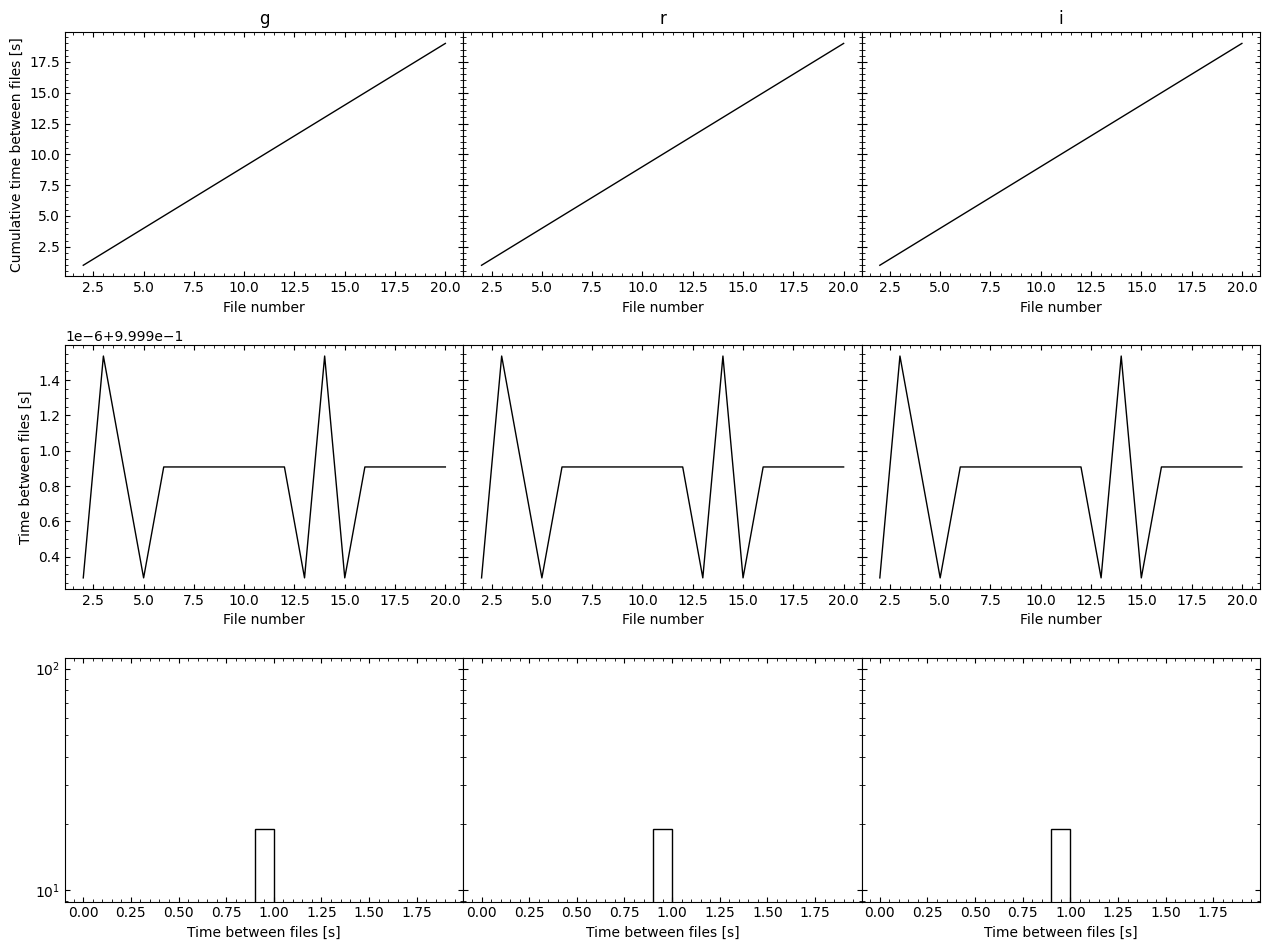

In [5]:
reducer = opticam.Reducer(
    data_directory=out_dir / 'data',  # path to the data
    out_directory=out_dir / 'reduced',  # path to where the output will be saved
    instrument=instrument,  # the instrument (defaults to OPTICAM_MX())
    )

After creating a `Reducer` instance, `opticam.scan_data()` is ran to ensure there are no issues with the data; as mentioned above, this may result in errors that will need to be resolved. In this case, however, we can see that there are no errors, and so we can proceed with reduction.

We can also see that our chosen instrument, `OPTICAM_MX` passed the internal checks. See the [custom instruments](instruments.ipynb) tutorial for guidance on how to create custom instruments for use with `opticam`, and fix potential errors that might arise when doing so.

## Create Source Catalogs

The next step is to create source catalogs for each camera. Creating source catalogs requires aligning each camera's images to track sources over time and ensure consistent labelling. The way in which images are aligned can be customised. By default, images will be aligned using `transform_type='affine'` which uses the [`astroalign`](https://astroalign.quatrope.org/en/latest/) package. Alternatively, passing `transform_type='translation'` will compute simple (x, y) translations between images. The number of reference sources can also be changed by passing the desired value to `n_alignment_sources`. When using `transform_type='translation'`, `n_alignment_sources` must be $\geq 1$ while `transform_type='affine'` requires `n_alignment_sources` be $\geq 3$.

To create the source catalogs, we must call the `create_catalogs()` method:

[OPTICAM] Creating source catalogs


[OPTICAM] Aligning g images:   0%|                                          |[00:00<?]

[OPTICAM] Aligning g images:   5%|█▉                                    |[00:01<00:35]

[OPTICAM] Aligning g images:  90%|██████████████████████████████████▏   |[00:01<00:00]

[OPTICAM] Aligning g images: 100%|██████████████████████████████████████|[00:01<00:00]

...

[OPTICAM] Done.
[OPTICAM] 20 image(s) aligned.
[OPTICAM] 0 image(s) could not be aligned.


[OPTICAM] Aligning i images:   0%|                                          |[00:00<?]

[OPTICAM] Aligning i images:   5%|█▉                                    |[00:01<00:36]

[OPTICAM] Aligning i images: 100%|██████████████████████████████████████|[00:01<00:00]

[OPTICAM] Done.
[OPTICAM] 20 image(s) aligned.
[OPTICAM] 0 image(s) could not be aligned.


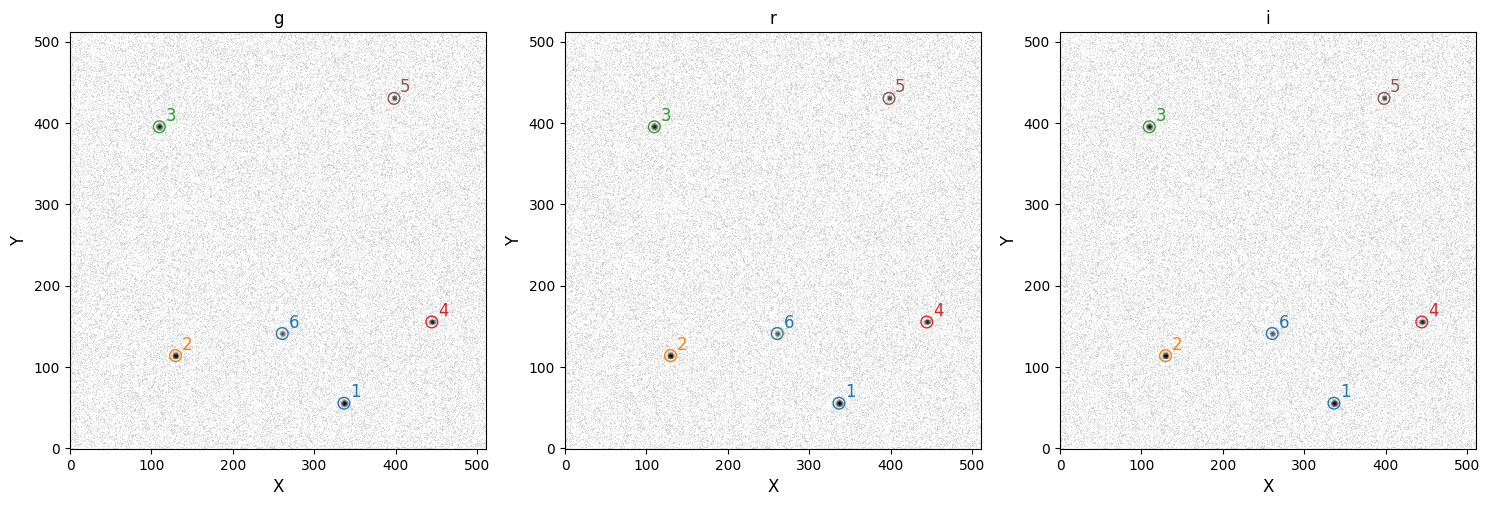

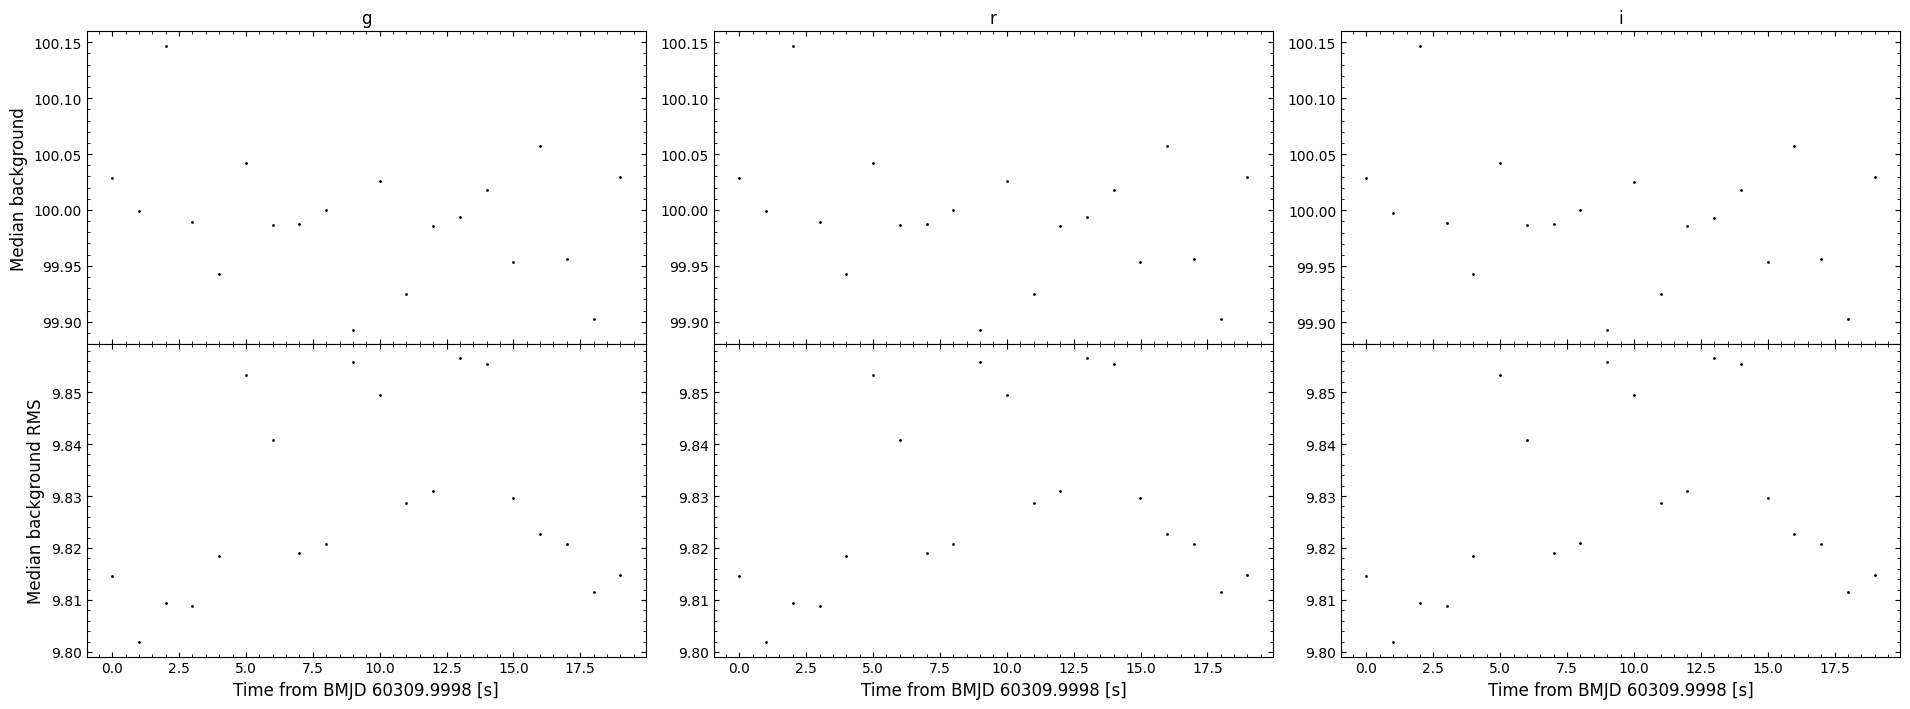

In [6]:
reducer.create_catalogs()

We can see that six sources have been identified in each of the three sets of images. In this example, the source labelling is consistent across the catalogs because there are no field-of-view or pixel-scale differences between the simulated cameras. In practise, the source labelling will not usually be consistent across the catalogs, and so care must be taken when performing differential photometry that the same sources are being used for each filter (more on this later).

## Performing Photometry

With our catalogs defined, we can now perform photometry. Performing photometry in `opticam` requires a photometer object that inherits from `opticam.photometers.BasePhotometer`. Currently, `opticam` provides two photometers: `AperturePhotometer`, for performing simple aperture photometry, and `OptimalPhotometer`, for performing optimal photometry (as described in [Naylor 1998](https://ui.adsabs.harvard.edu/abs/1998MNRAS.296..339N/abstract)). Both photometers can be configured to perform "forced photometry", and can use either the `Reducer`'s 2D background estimator or estimate the local background around each source using an annulus. In this example, I'll show a couple of different photometry configurations:

In [7]:
# aperture photometer with local background estimations
default_annulus_photometer = opticam.AperturePhotometer(
    local_background_estimator=opticam.DefaultLocalBackground(),  # use the default local background estimator
)

# optimal photometer
# implements the method described in Naylor 1998, MNRAS, 296, 339-346
optimal_photometer = opticam.OptimalPhotometer()

Once a photometer has been defined, it can be passed to the `photometry()` method of `Catalog` to compute the raw light curves:

[OPTICAM] Photometry results will be saved to lcs/aperture_annulus in out/reduced.


[OPTICAM] Performing photometry on g images:   0%|                          |[00:00<?]

[OPTICAM] Performing photometry on g images:   5%|█                     |[00:01<00:35]

[OPTICAM] Performing photometry on g images: 100%|██████████████████████|[00:01<00:00]

[OPTICAM] Performing photometry on r images:   0%|                          |[00:00<?]

...

[OPTICAM] Performing photometry on r images:  60%|█████████████▏        |[00:01<00:00]

[OPTICAM] Performing photometry on r images: 100%|██████████████████████|[00:01<00:00]

[OPTICAM] Performing photometry on i images:   0%|                          |[00:00<?]

[OPTICAM] Performing photometry on i images:   5%|█                     |[00:01<00:34]

[OPTICAM] Performing photometry on i images: 100%|██████████████████████|[00:01<00:00]

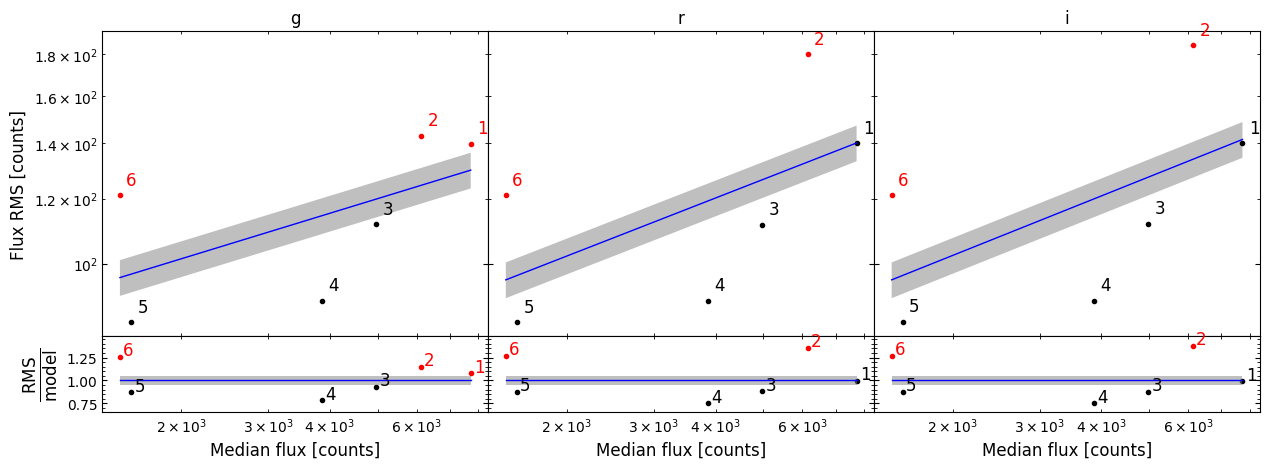

In [8]:
reducer.photometry(default_annulus_photometer)  # using the aperture photometer with local background estimations

When you perform photometry on a catalog, the directory to which the light curves are saved will depend on how the photometer is configured:
1. If the photometer is defined with `forced=True`, the directory will have a "forced" prefix.
2. If a local background estimator is passed to the photometer's `local_background_estimator` parameter, then the directory will also have an "annulus" suffix.

In the above case, we used the `AperturePhotometer` with a local background estimator and so we can see that the raw light curves have been saved to a `lcs/aperture_annulus` directory. Let's compare this to the subdirectory for light curves produced by our `optimal_photometer`:

[OPTICAM] Photometry results will be saved to lcs/optimal in out/reduced.


[OPTICAM] Performing photometry on g images:   0%|                          |[00:00<?]

[OPTICAM] Performing photometry on g images:   5%|█                     |[00:02<00:51]

[OPTICAM] Performing photometry on g images:  65%|██████████████▎       |[00:02<00:01]

[OPTICAM] Performing photometry on g images: 100%|██████████████████████|[00:02<00:00]

...

[OPTICAM] Performing photometry on r images: 100%|██████████████████████|[00:02<00:00]

[OPTICAM] Performing photometry on i images:   0%|                          |[00:00<?]

[OPTICAM] Performing photometry on i images:   5%|█                     |[00:02<00:51]

[OPTICAM] Performing photometry on i images:  25%|█████▌                |[00:02<00:06]

[OPTICAM] Performing photometry on i images: 100%|██████████████████████|[00:02<00:00]

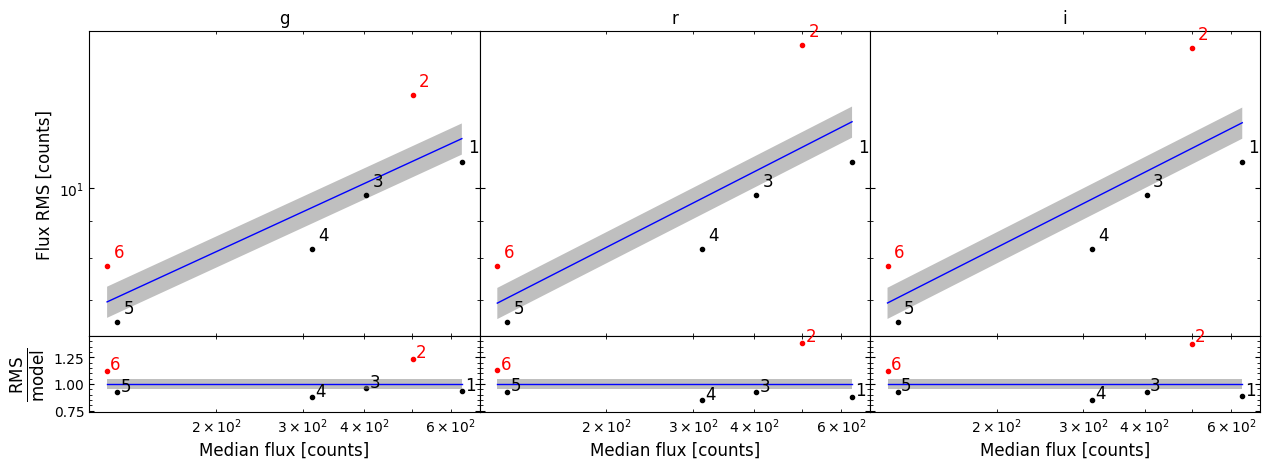

In [9]:
reducer.photometry(optimal_photometer)  # using the optimal photometer

In this case there is no prefix nor suffix, and only the name of the photometer class is included.

## Computing Relative Light Curves

We now have some raw light curves using a couple of different photometry configurations. However, raw light curves contain a lot of atmospheric and systematic variability, and so we often want to compute the relative light curve between our source of interest and some comparison sources to reduce this atmospheric/systematic variability.

In this example, let's say that Source 6 is our target of interest (since we know that it's varying), and use Source 5 for comparison. In this example, the choice of comparison source(s) is arbitraray (since there are no atmospheric/systematic variations in our simulated data). In practise, however, choosing suitable comparison sources is vital for obtaining quality light curves, though a discussion of this is beyond the scope of this tutorial.

Let's now produce a relative light curve for Source 6 using the "aperture_annulus" light curves created by `default_annulus_photometer`. First, however, we need to initialise a `DifferentialPhotometer` object. When initialising a `DifferentialPhotometer` object, we need to pass the directory path to the reduced data created by `Reducer`:

[OPTICAM] Filters: g, r, i


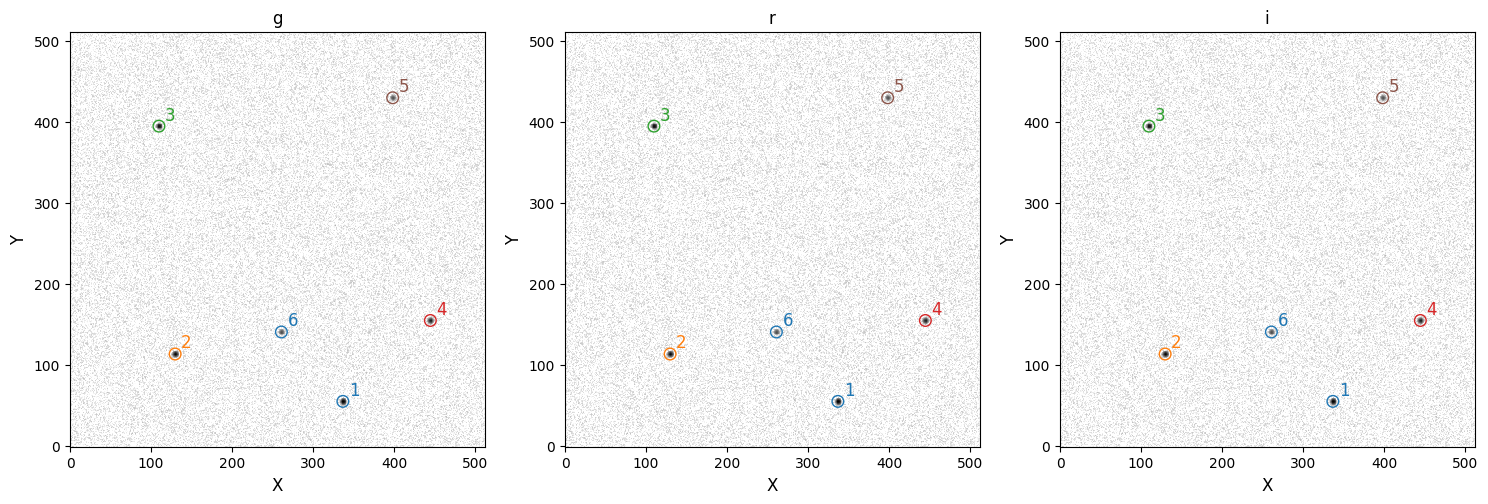

In [10]:
dphot = opticam.DifferentialPhotometer(
    out_directory=out_dir / 'reduced',  # same as the catalog's out_directory
    show_plots=True,  # show plots (useful for diagnosis and debugging)
    )

When initialising a `DifferentialPhotometer` object, the source catalogs are output for convenience (unless `show_plots=False`). We can now create our relative light curves:

[OPTICAM] g target ID 2 was matched to r target ID 2
[OPTICAM] r comparison ID 1 was matched to r comparison ID 1
[OPTICAM] g target ID 2 was matched to i target ID 2
[OPTICAM] i comparison ID 1 was matched to i comparison ID 1


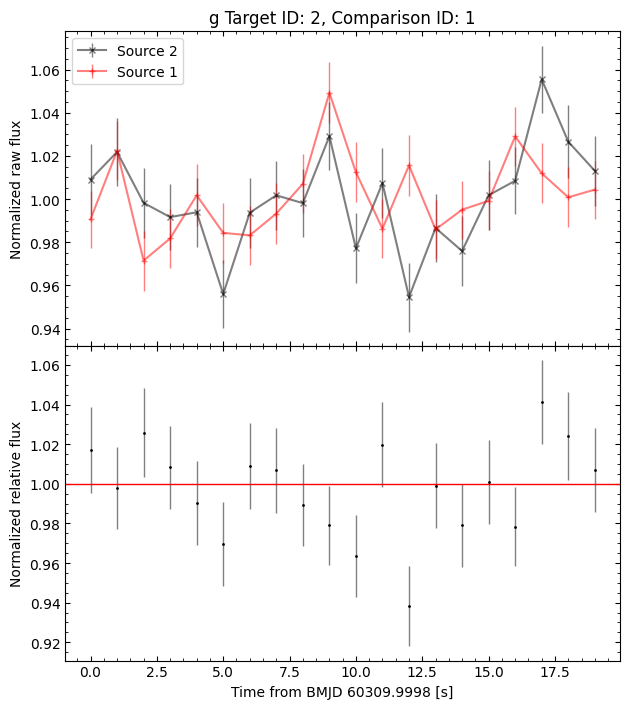

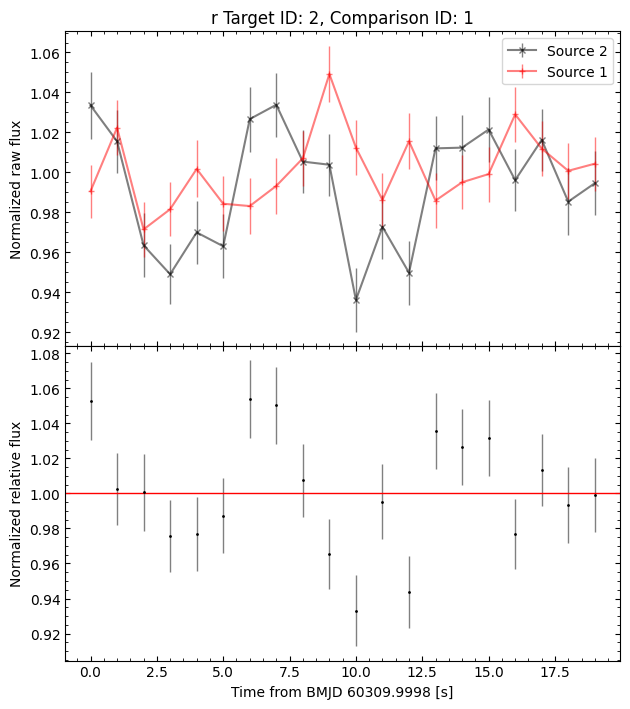

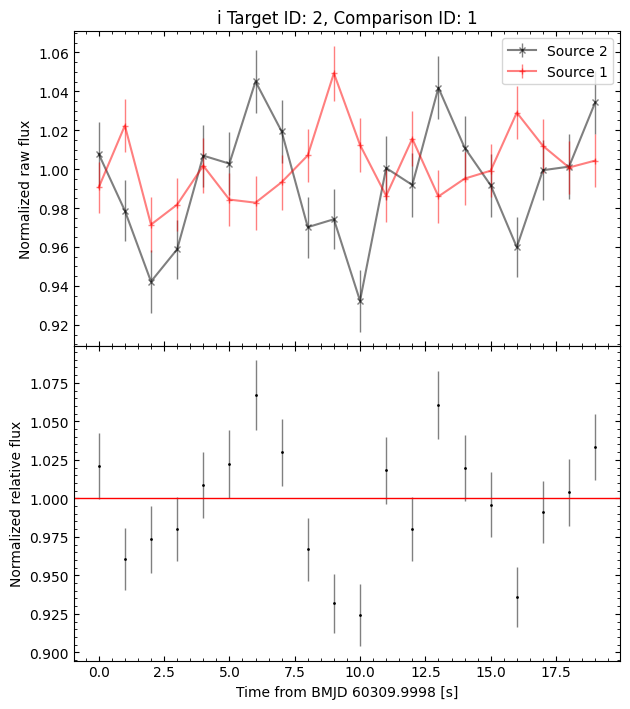

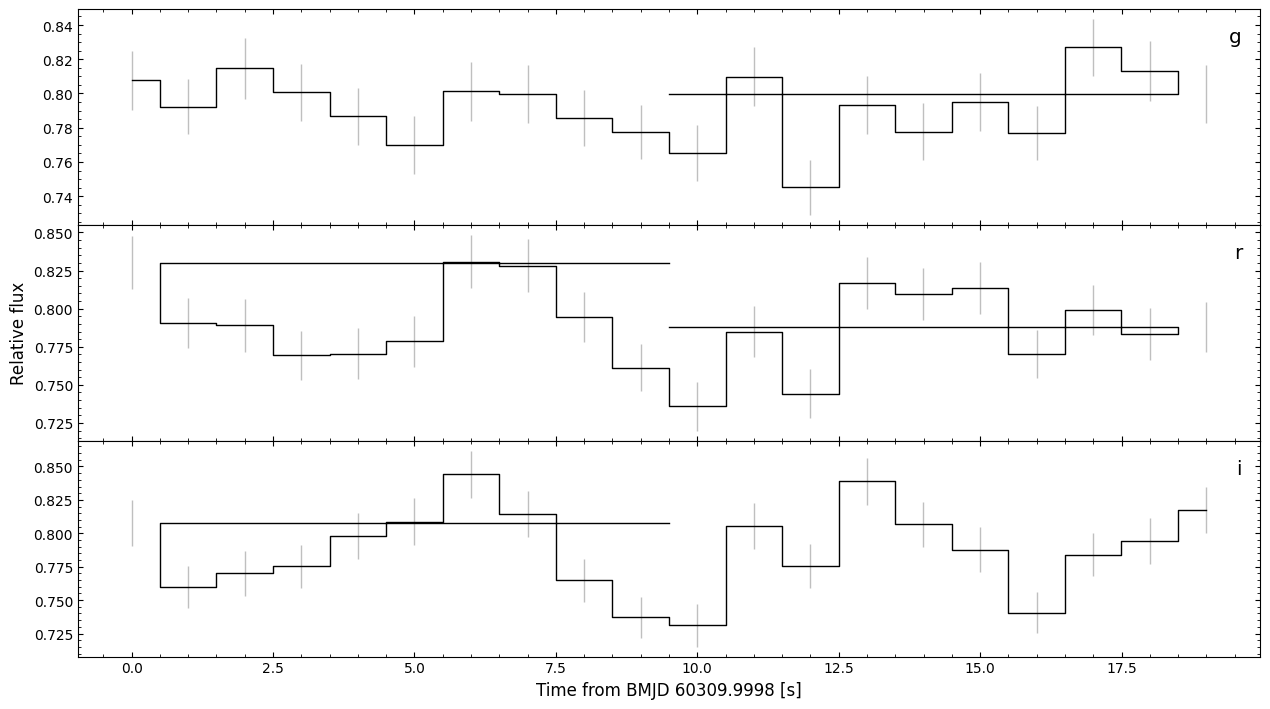

In [11]:
target = 2  # source of interest
comparisons = [1]  # comparison sources

annulus_analyzer = dphot.get_relative_light_curve(
    'g',  # filter for which to compute the relative light curve
    target,  # source of interest
    comparisons,  # comparison sources
    phot_label='aperture_annulus',  # label for the photometry results
    prefix='test',  # prefix for the output files (e.g., the name of the target source)
    match_other_cameras=True,  # match sources across cameras
    show_diagnostics=True,  # show diagnostic plots (useful for diagnosis and debugging)
    )

While the relative light curves are generated, a number of diagnostic plots are rendered. These diagnostic plots can be suppressed by passing `show_diagnostics=False`. Regardless of the value of `show_diagnostics`, these diagnostic plots are saved to `out_directory/relative_light_curves/diag`. The resulting relative light curves are also shown for convenience. After relative light curves have been computed, an `Analyzer` object is returned (see the [timing methods](timing_methods.ipynb) tutorial for more details on this).

Above, we used the `get_relative_light_curve()` method to automatically match sources across filters by setting `match_other_cameras=True`. However, this can misidentify sources, so care should be taken to check the correct sources are identified. In this case, we can see that the identified sources are correct, and so we don't have to manually create relative light curves for each filter. For the optimal light curves, however, I will show how to merge `Analyzer` instances using the `join()` method should you ever have to match the sources manually. First, let's define the individual `Analyzer` instances:

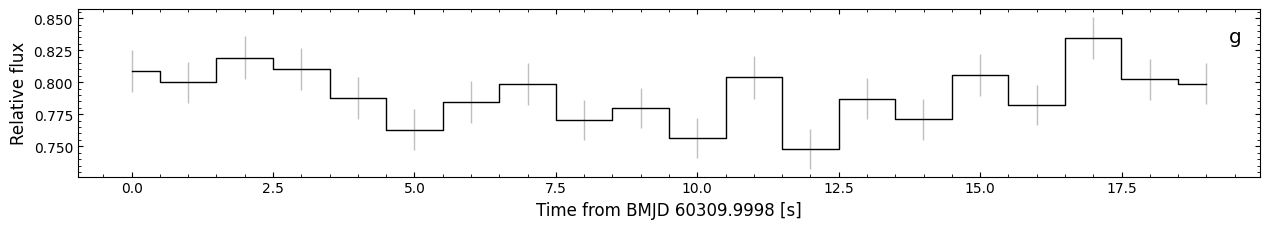

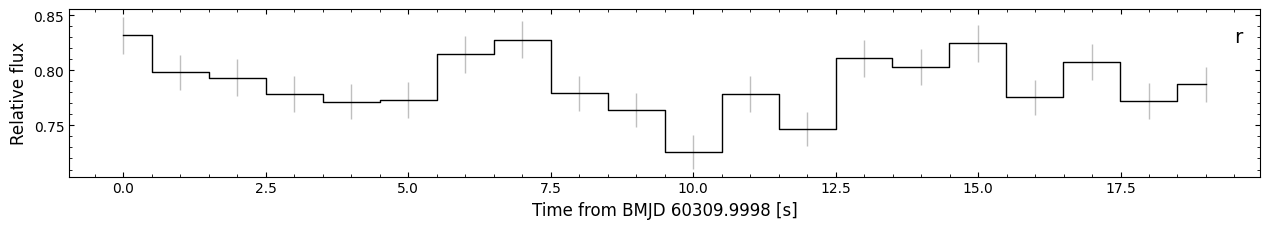

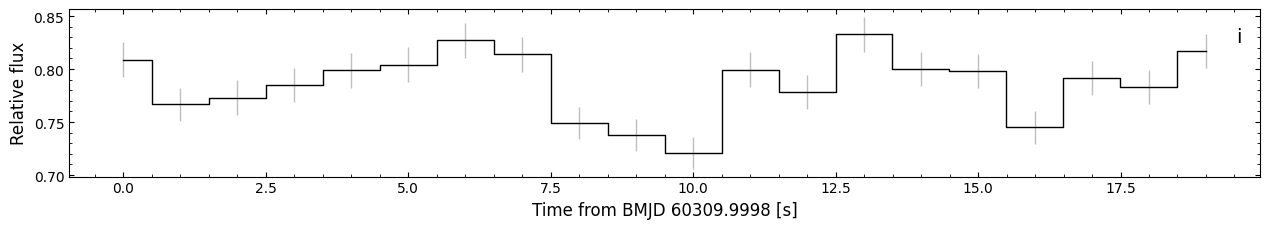

In [12]:
g_band_optimal_analyzer = dphot.get_relative_light_curve(
    'g',
    target,
    comparisons,
    phot_label='optimal',
    prefix='test',
    match_other_cameras=False,
    show_diagnostics=False,
    )

r_band_optimal_analyzer = dphot.get_relative_light_curve(
    'r',
    target,
    comparisons,
    phot_label='optimal',
    prefix='test',
    match_other_cameras=False,
    show_diagnostics=False,
    )

i_band_optimal_analyzer = dphot.get_relative_light_curve(
    'i',
    target,
    comparisons,
    phot_label='optimal',
    prefix='test',
    match_other_cameras=False,
    show_diagnostics=False,
    )

Now let's combine them all into a single instance:

In [13]:
# join g-band with r-band
optimal_analyzer = g_band_optimal_analyzer.join(r_band_optimal_analyzer)

# join g-band and r-band with i-band
optimal_analyzer = optimal_analyzer.join(i_band_optimal_analyzer)

To check the `Analyzer` instances have merged properly, let's try plotting the light curves:

[OPTICAM] Plot saved to out/reduced/plots/test_optimal_light_curves.pdf.


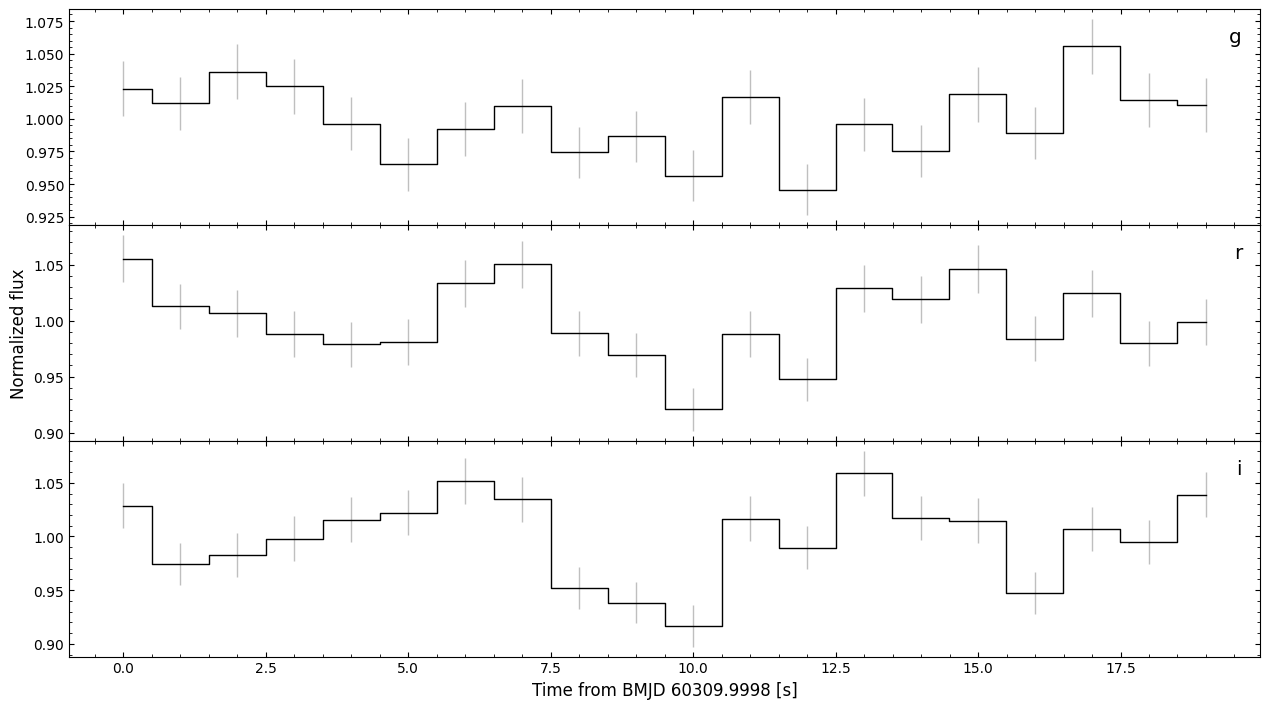

In [14]:
fig = optimal_analyzer.plot()

As we can see, all three light curves have been combined successfully combined into a single `Analyzer` instance.

That concludes the reduction tutorial for `opticam`! If you're using `opticam` to reduce data from OPTICAM-MX, I recommend checking out the [applying corrections](applying_corrections.ipynb) and [photometry](photometry.ipynb) tutorials next. To use `opticam` with another instrument, check out the [custom instruments](instruments.ipynb) tutorial. To explore the quick-look timing analysis routines available in `opticam`, see the [timing methods tutorial](timing_methods.ipynb).